In [2]:
import numpy as np

def compute_epsilon_u(epsilon_p, gamma, m, n, r):
    """
    Compute epsilon_u based on the AugCorBin-FL mechanism theorem
    
    Parameters:
    -----------
    epsilon_p : float
        Privacy parameter ϵₚ
    gamma : float
        Parameter gamma ∈ (0,1]
    m : int
        Number of model parameters parameter
    n : int
        Number of samples (must satisfy the theorem's condition)
    r : float
        Maximum of r_j values
    alpha_fn : callable
        Function that computes alpha(ϵₚ)
    
    Returns:
    --------
    float
        Computed value of ϵᵤ
    """
    delta = 1e-5
    
    # Verify the condition from the theorem
    alpha_eps = (1+ np.exp(epsilon_p))/(np.exp(epsilon_p)-1)
    condition = (n * gamma - 1) * (1/4 - 1/(4 * alpha_eps**2))
    # print('first term in max', 23 * np.log(m/delta))
    # print('second term in max', 2 * r * alpha_eps)
    # print('-'*50)
    required_value = max(23 * np.log(m/delta), 2 * r * alpha_eps)
    
    if condition < required_value:
        print("n is not large enough to satisfy the theorem's condition")
        print(f"Condition: {condition}")
        print(f"Required value: {required_value}")
        print('-'*50)

        # raise ValueError("n is not large enough to satisfy the theorem's condition")
    
    # Compute e_p and b_p
    e_p = (1 + 1/alpha_eps**2)
    b_p = (1/3) * e_p + 1/alpha_eps
    
    # Compute the two terms under the square root
    numerator1 = 8 * m * np.log(1.25/delta)
    denominator1 = (n * gamma - 1) * e_p
    print('numerator1', numerator1)
    print('denominator1', denominator1)
    term1 = np.sqrt(numerator1 / denominator1)

    numerator2 = 8 *( np.log(1.25/delta) + np.log(20 * m/delta) * np.log(10/delta))
    denominator2 = 3 * (n * gamma - 1)
    term2 = numerator2 / denominator2
    
    # Compute the third term
    numerator3 = 4 * b_p * np.sqrt(2 * m) * (1.75 + 3.75/alpha_eps**2) * np.sqrt(np.log(10/delta))
    denominator3   = (n * gamma - 1) * (1 - delta/10) * e_p
    term3 = (4 * b_p * np.sqrt(2 * m) * (1.75 + 3.75/alpha_eps**2) * np.sqrt(np.log(10/delta))) / ((n * gamma - 1) * (1 - delta/10) * e_p)
    
    print(term1, term2, term3)
    print(term1)
    print(term1+term2)
    print(term1+term2+term3)
    print("alpha_epsilon", alpha_eps)
    # Combine all terms
    epsilon_u = (term1 + term2 + term3) * r * alpha_eps
    
    return epsilon_u

In [23]:
epsilon_p = 1
gamma = 0.4
m = 1e6
n = 1e3
r = 1e-2
print("the epsilon_c",compute_epsilon_u(epsilon_p, gamma, m, n, r))

n is not large enough to satisfy the theorem's condition
Condition: 78.44816136335126
Required value: 582.5540285274936
--------------------------------------------------
numerator1 93888552.1302755
denominator1 484.20735454659496
440.3425267165398 2.693727085460172 95.99387189292153
440.3425267165398
443.036253802
539.0301256949215
alpha_epsilon 2.163953413738653
the epsilon_c 11.664360806055004


Mean of X for epsilon_p=0.1: -0.000000
Second moment sum for epsilon_p=0.1: 200.161793
Third moment sum for epsilon_p=0.1: 401.000200
Mean of X for epsilon_p=0.5: 0.000000
Second moment sum for epsilon_p=0.5: 8.163773
Third moment sum for epsilon_p=0.5: 3.401044
Mean of X for epsilon_p=1.0: -0.000000
Second moment sum for epsilon_p=1.0: 2.169724
Third moment sum for epsilon_p=1.0: 0.502340
Mean of X for epsilon_p=2.0: -0.000000
Second moment sum for epsilon_p=2.0: 0.690407
Third moment sum for epsilon_p=2.0: 0.106073
Mean of X for epsilon_p=4.0: 0.000000
Second moment sum for epsilon_p=4.0: 0.366387
Third moment sum for epsilon_p=4.0: 0.046803
Mean of X for epsilon_p=8: 0.000000
Second moment sum for epsilon_p=8: 0.329048
Third moment sum for epsilon_p=8: 0.040765
Mean of X for epsilon_p=10: 0.000000
Second moment sum for epsilon_p=10: 0.328467
Third moment sum for epsilon_p=10: 0.040673


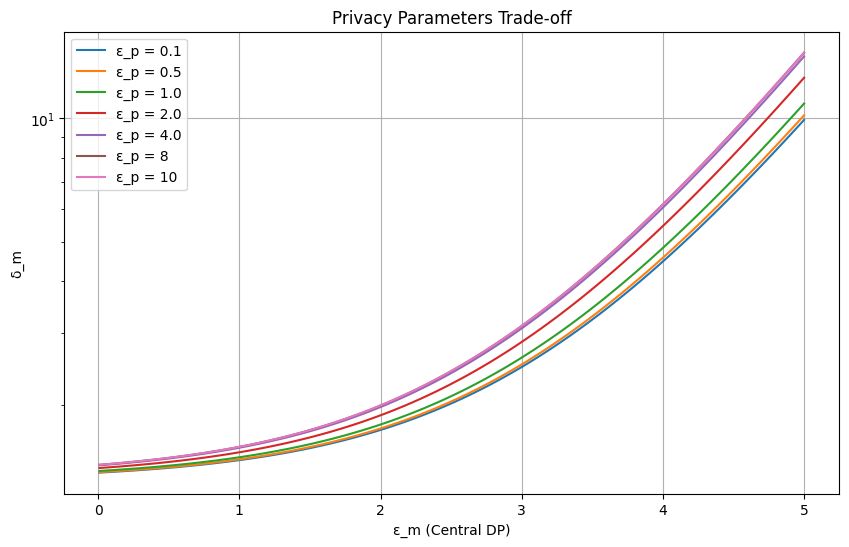


For ε_p = 0.1:
Min δ_m: 1.366613
Max ε_m: 5.000000

For ε_p = 0.5:
Min δ_m: 1.370074
Max ε_m: 5.000000

For ε_p = 1.0:
Min δ_m: 1.379439
Max ε_m: 5.000000

For ε_p = 2.0:
Min δ_m: 1.402272
Max ε_m: 5.000000

For ε_p = 4.0:
Min δ_m: 1.423794
Max ε_m: 5.000000

For ε_p = 8:
Min δ_m: 1.427858
Max ε_m: 5.000000

For ε_p = 10:
Min δ_m: 1.427925
Max ε_m: 5.000000


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Initial parameters
c = 0.0  # center
r = 0.1  # range
n = 50  # number of clients
d = 1e6   # dimension of the data
epsilon_p_values = [0.1, 0.5, 1.0, 2.0, 4.0, 8, 10]  # different PLDP privacy parameters
C_0 = 0.4097  # Berry-Esseen constant

# Generate random weights
w = np.random.uniform(c-r, c+r, n)

# Function to compute alpha
def compute_alpha(eps_p):
    return -(1 + np.exp(eps_p)) / (1 - np.exp(eps_p))

# Arrays to store results for different epsilon_p values
all_epsilon_m = []
all_delta_m = []

for epsilon_p in epsilon_p_values:
    # Compute alpha
    alpha = compute_alpha(epsilon_p)
    
    # Compute probabilities for mechanism M
    p1 = 0.5 + (w - c)/(2*alpha*r)
    p2 = 1 - p1
    
    # For each X_i:
    # X_i = (c + alpha*r) - w_i with probability p1
    # X_i = (c - alpha*r) - w_i with probability p2
    
    # Theoretical moments for each X_i
    # First moment (mean) should be 0
    X_values1 = (c + alpha*r) - w  # possible values for X when first outcome
    X_values2 = (c - alpha*r) - w  # possible values for X when second outcome
    mean_X = p1 * X_values1 + p2 * X_values2
    print(f"Mean of X for epsilon_p={epsilon_p}: {np.sum(mean_X):.6f}")  # Should be very close to 0
    
    # Second moment (E[X²])
    second_moment = p1 * X_values1**2 + p2 * X_values2**2
    print(f"Second moment sum for epsilon_p={epsilon_p}: {np.sum(second_moment):.6f}")
    
    # Third moment (E[|X³|])
    third_moment = p1 * np.abs(X_values1**3) + p2 * np.abs(X_values2**3)
    print(f"Third moment sum for epsilon_p={epsilon_p}: {np.sum(third_moment):.6f}")
    
    # Compute Sigma and psi_0
    sigma_squared = second_moment  # Variance for each X_i
    Sigma = np.sqrt(np.sum(sigma_squared))
    psi_0 = (np.sum(sigma_squared)**(-3/2)) * np.sum(third_moment)
    
    # Generate epsilon_m values
    epsilon_m = np.linspace(0.01, 5.0, 100)
    
    # Compute corresponding delta_m values
    delta_m = (np.exp(epsilon_m) + 1) * C_0 * psi_0 + 1.25 * np.exp(-(alpha**2 * epsilon_m**2)/(8*n*d))
    
    # Filter out invalid points (where delta_m <= 0)
    valid_indices = delta_m > 0
    epsilon_m = epsilon_m[valid_indices]
    delta_m = delta_m[valid_indices]
    
    all_epsilon_m.append(epsilon_m)
    all_delta_m.append(delta_m)

# Plot epsilon-delta curves
plt.figure(figsize=(10, 6))
for i, eps_p in enumerate(epsilon_p_values):
    plt.plot(all_epsilon_m[i], all_delta_m[i], label=f'ε_p = {eps_p}')

plt.xlabel('ε_m (Central DP)')
plt.ylabel('δ_m')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.title('Privacy Parameters Trade-off')
plt.show()

# Print some statistics
for i, eps_p in enumerate(epsilon_p_values):
    print(f"\nFor ε_p = {eps_p}:")
    print(f"Min δ_m: {np.min(all_delta_m[i]):.6f}")
    print(f"Max ε_m: {np.max(all_epsilon_m[i]):.6f}")

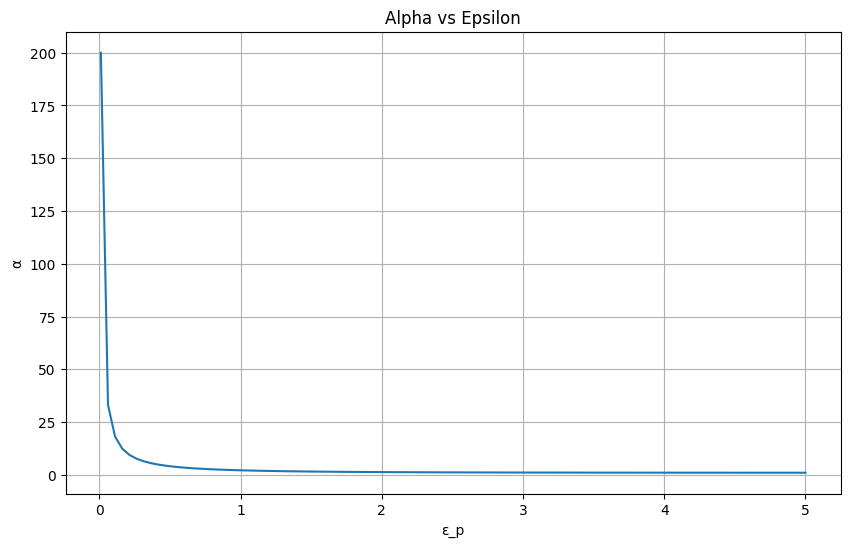

In [13]:
# plot alpha for different epsilon values
epsilon_p_values = np.linspace(0.01, 5.0, 100)
alpha_values = compute_alpha(epsilon_p_values)

plt.figure(figsize=(10, 6))
plt.plot(epsilon_p_values, alpha_values)
plt.xlabel('ε_p')
plt.ylabel('α')
plt.grid(True)
plt.title('Alpha vs Epsilon')
plt.show()